
# Digital Marketing Campaign Conversion Prediction (Capstone)

**Author:** Your Name  
**Dataset:** `digital_marketing_campaign_dataset.xlsx`  
**Goal:** Predict whether a user will convert using demographic, engagement, and campaign features to improve ROAS.

---



## Project Outline
1. Problem Definition & Business Context  
2. Data Loading & Quick View  
3. Exploratory Data Analysis (EDA)  
4. Data Preprocessing (missing values, encoding, scaling)  
5. Model Training & Selection (LogReg, RF, GB)  
6. Evaluation (F1, Confusion Matrix, ROC, PR)  
7. Feature Importance & Insights  
8. Export Trained Model  
9. Inference on New Data


In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

pd.set_option("display.max_columns", 100)

In [2]:
DATA_PATH = "digital_marketing_campaign_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (8000, 20)


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1



# 3. TARGET DETECTION


In [3]:
TARGET_CANDIDATES = ["conversion","converted","is_converted","response","target","label","y"]
ID_LIKE = {"customerid","id","user_id","userid"}

# Drop ID columns
df = df.drop(columns=[c for c in df.columns if c.lower() in ID_LIKE], errors="ignore")

# Detect target
target_col = None
for col in df.columns:
    if col.lower() in TARGET_CANDIDATES:
        target_col = col
        break

if target_col is None:
    raise Exception("❌ Target column not found")

print("Target Column:", target_col)

# Split data
X = df.drop(columns=[target_col])
y = df[target_col]

# Column types
cat_cols = X.select_dtypes(include=["object","category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical Columns:", cat_cols)
print("Numeric Columns:", num_cols)

Target Column: Conversion
Categorical Columns: ['Gender', 'CampaignChannel', 'CampaignType', 'AdvertisingPlatform', 'AdvertisingTool']
Numeric Columns: ['Age', 'Income', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints']


# 4. EDA


Class Balance:
Conversion
1    0.8765
0    0.1235
Name: proportion, dtype: float64

Missing Values:
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64


,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500
std,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162
min,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000
50%,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000
75%,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000
max,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000


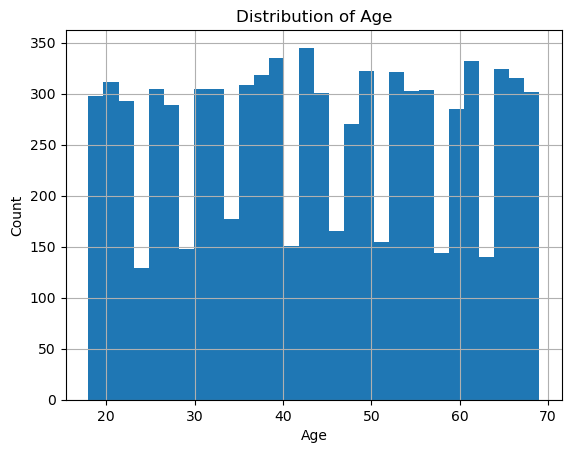

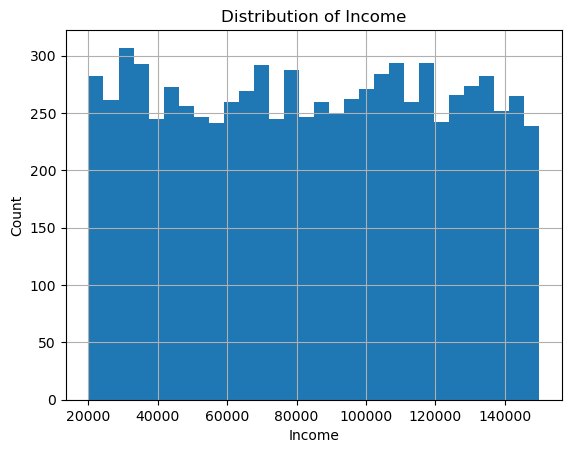

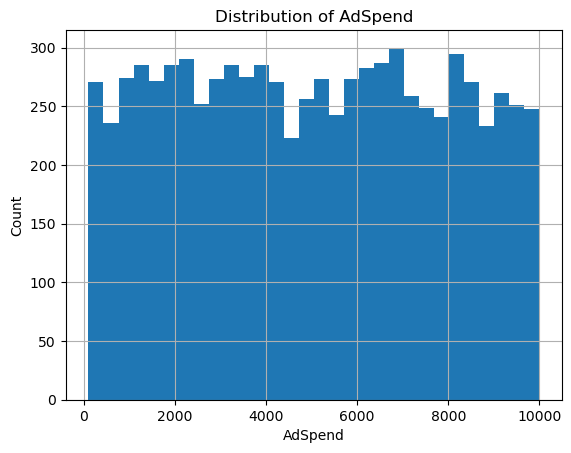

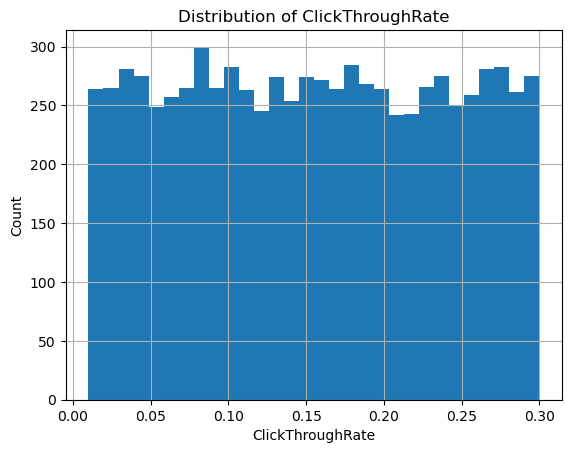

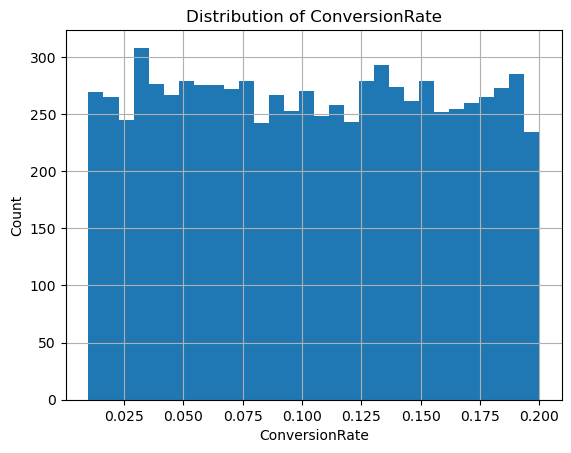

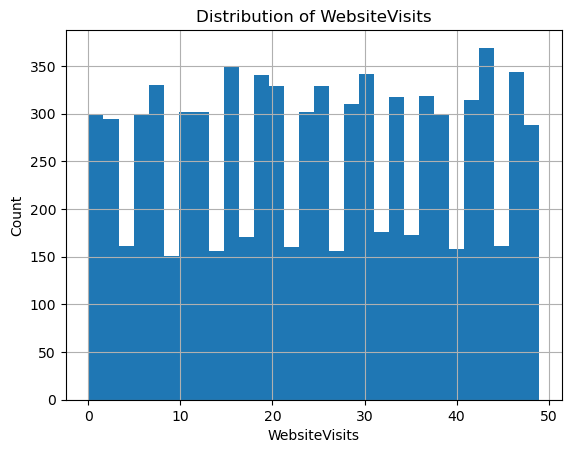

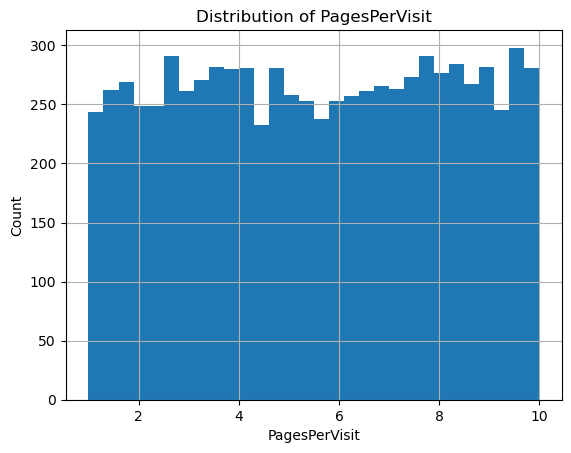

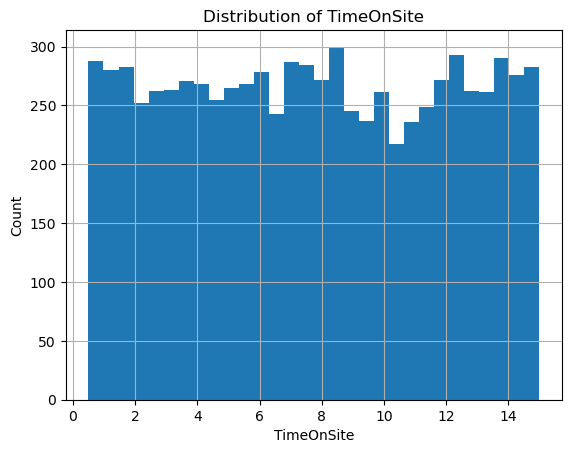

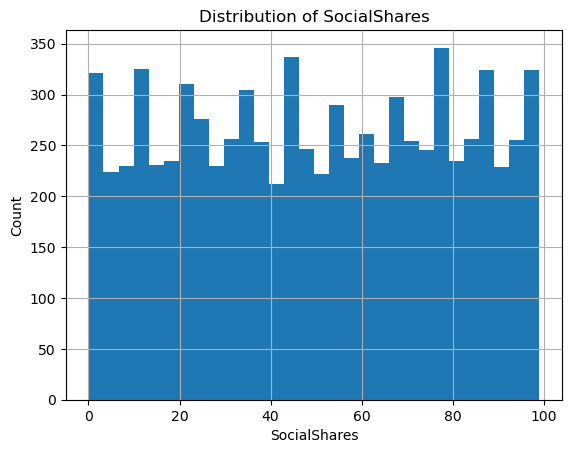

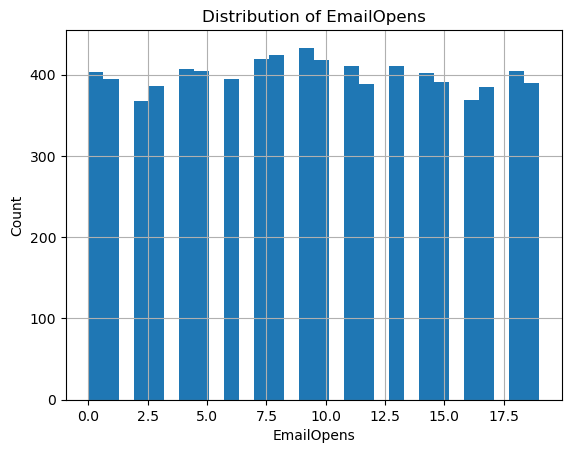

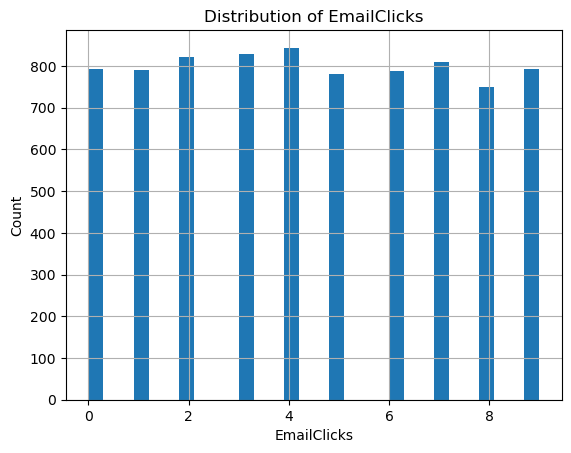

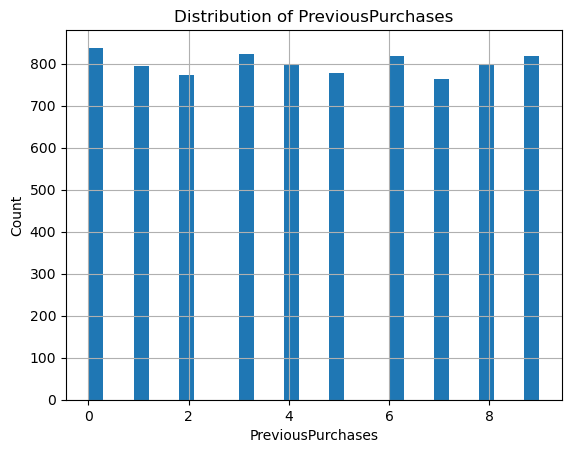

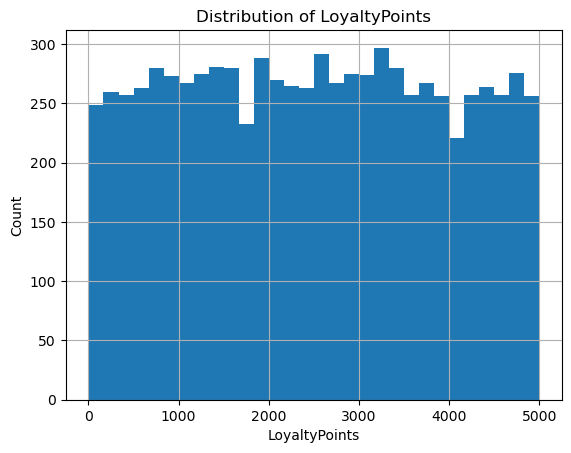

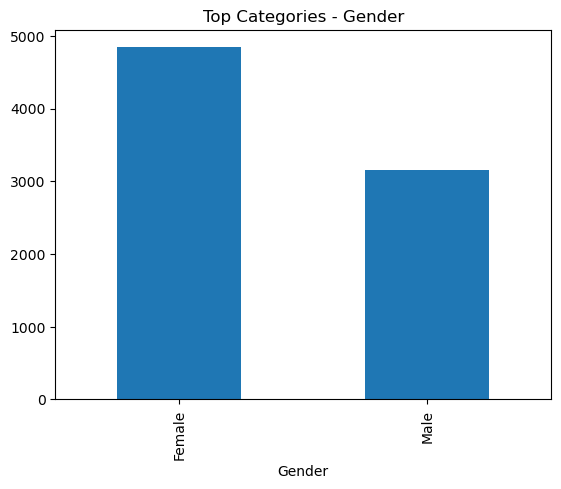

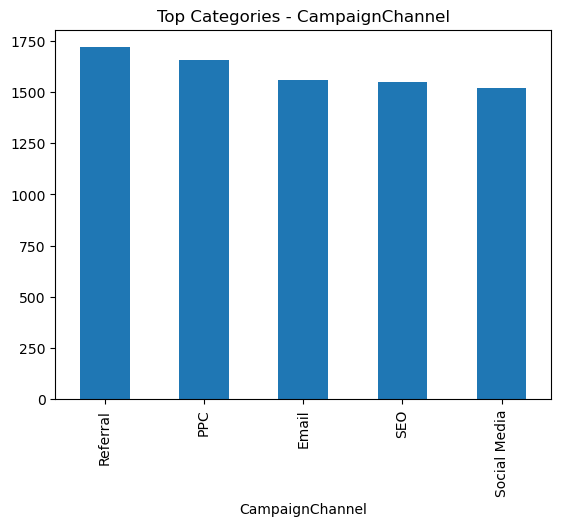

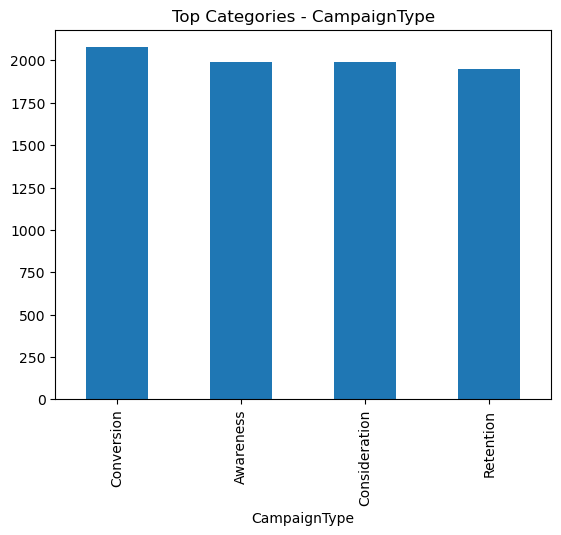

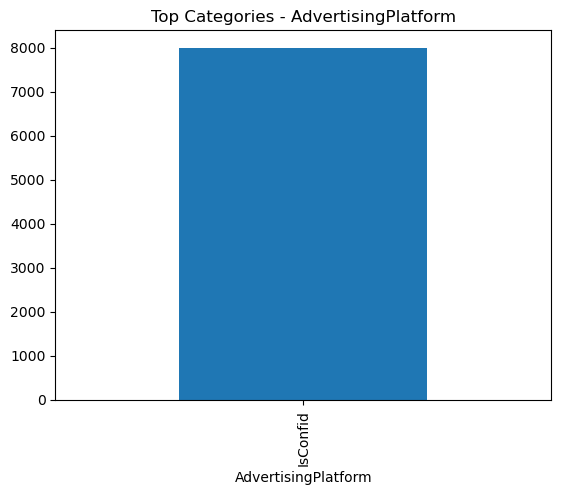

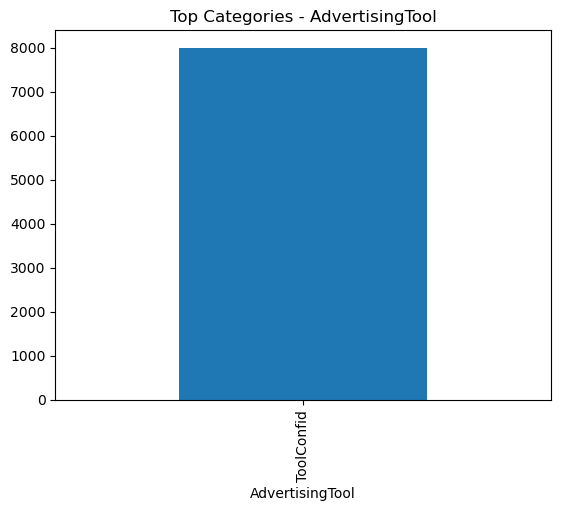

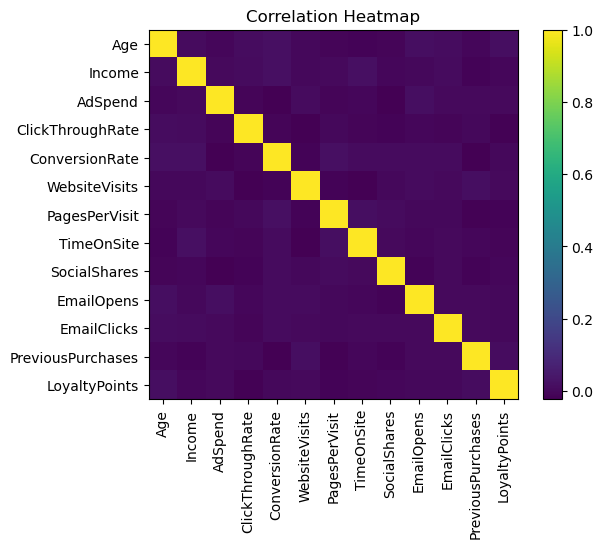

In [4]:
# Class balance
print("\nClass Balance:")
print(y.value_counts(normalize=True))

# Missing values
print("\nMissing Values:")
print(df.isna().sum())

# Numeric summary
display(df[num_cols].describe())

# Histograms
for col in num_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# Categorical plots
for col in cat_cols:
    plt.figure()
    df[col].value_counts().head(20).plot(kind="bar")
    plt.title(f"Top Categories - {col}")
    plt.show()

# Correlation heatmap
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    plt.figure()
    plt.imshow(corr)
    plt.colorbar()
    plt.xticks(range(len(num_cols)), num_cols, rotation=90)
    plt.yticks(range(len(num_cols)), num_cols)
    plt.title("Correlation Heatmap")
    plt.show()


# 5. PREPROCESSING

In [5]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. MODEL TRAINING

In [6]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv,
        scoring=["accuracy","precision","recall","f1"],
        return_train_score=False
    )

    cv_results[name] = {k: np.mean(v) for k, v in scores.items() if "test" in k}

    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

# Show CV results
print("\nCross Validation Results:")
print(pd.DataFrame(cv_results).T)


Training LogisticRegression...

Training RandomForest...

Training GradientBoosting...

Cross Validation Results:
                    test_accuracy  test_precision  test_recall   test_f1
LogisticRegression       0.892188        0.897165     0.990553  0.941545
RandomForest             0.891875        0.891072     0.998752  0.941842
GradientBoosting         0.918281        0.918003     0.995722  0.955281


# 7. BEST MODEL SELECTION

In [7]:

best_model_name = max(cv_results, key=lambda x: cv_results[x]["test_f1"])
best_model = trained_models[best_model_name]

print("\nBest Model:", best_model_name)


Best Model: GradientBoosting


# 8. EVALUATION

In [8]:
y_pred = best_model.predict(X_test)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred, zero_division=0)
}

print("\nEvaluation Metrics:")
print(json.dumps(metrics, indent=2))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Evaluation Metrics:
{
  "Accuracy": 0.91,
  "Precision": 0.9127296587926509,
  "Recall": 0.9921540656205421,
  "F1 Score": 0.950786056049214
}

Confusion Matrix:
[[  65  133]
 [  11 1391]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.33      0.47       198
           1       0.91      0.99      0.95      1402

    accuracy                           0.91      1600
   macro avg       0.88      0.66      0.71      1600
weighted avg       0.91      0.91      0.89      1600



# 9. ROC & PR CURVES

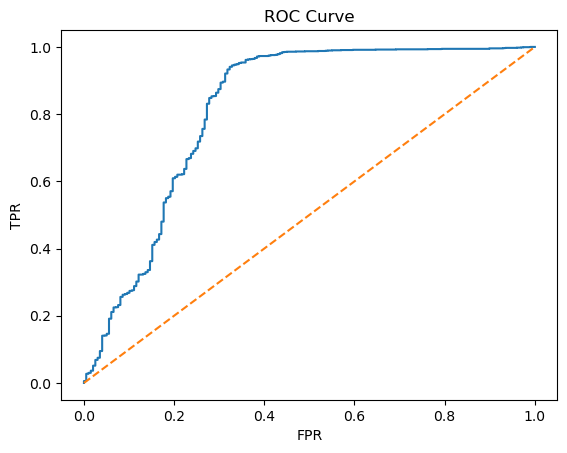

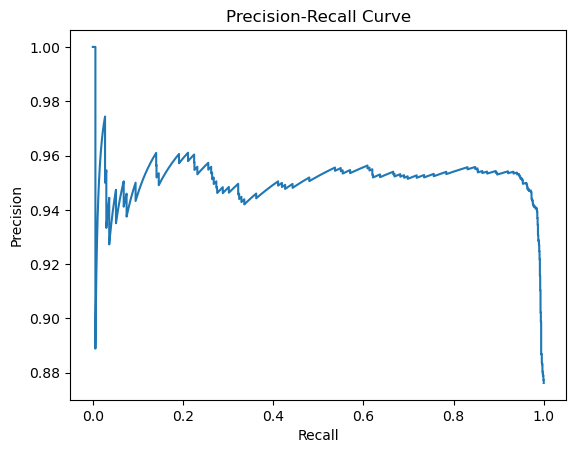

In [9]:
if hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_test)[:,1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],"--")
    plt.title("ROC Curve")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.show()

    # PR Curve
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    plt.figure()
    plt.plot(rec, prec)
    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

# 10. FEATURE IMPORTANCE

In [10]:
model = best_model.named_steps["model"]

if hasattr(model, "feature_importances_"):
    print("\nFeature Importance Available (Tree Model)")
elif hasattr(model, "coef_"):
    print("\nCoefficients Available (Linear Model)")


Feature Importance Available (Tree Model)


# 11. SAVE MODEL

In [11]:
joblib.dump(best_model, "dm_conversion_best_model.pkl")
print("\nModel saved successfully!")


Model saved successfully!


# 12. SAMPLE PREDICTION

In [12]:
# =========================
# 12. SAMPLE PREDICTION (FINAL)
# =========================

print("\n--- Sample Prediction (Row from Dataset) ---")
sample = X.iloc[[0]]
pred1 = best_model.predict(sample)[0]

print("Prediction (existing data):", pred1)


print("\n--- Sample Prediction (Generated Input) ---")
example = {}

for col in X.columns:
    if col in num_cols:
        example[col] = [float(X[col].median())]
    else:
        example[col] = [X[col].mode().iloc[0]]

sample_df = pd.DataFrame(example)

pred_class = best_model.predict(sample_df)[0]

pred_prob = None
if hasattr(best_model, "predict_proba"):
    pred_prob = best_model.predict_proba(sample_df)[:,1][0]

print("Prediction (new data):", int(pred_class))
print("Probability:", float(pred_prob) if pred_prob is not None else None)


--- Sample Prediction (Row from Dataset) ---
Prediction (existing data): 1

--- Sample Prediction (Generated Input) ---
Prediction (new data): 1
Probability: 0.9831093013474096
